In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import eda_utils as EDA
from Preprocessing import UniversalPreprocessor

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('credit_data.csv')

print("🔍 Размер датасета:", df.shape)
print("\n📊 Первые 5 строк:")
df.head()

🔍 Размер датасета: (150000, 12)

📊 Первые 5 строк:


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
print("📋 Информация о датасете:")
print(df.info())

print("\n🔍 Описательная статистика:")
print(df.describe())

print("\n❓ Пропущенные значения:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

print("\n🎯 Распределение целевой переменной:")
print(df['SeriousDlqin2yrs'].value_counts())

print("\n📊 Уникальные значения в каждой колонке:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} уникальных значений")

📋 Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null 

In [4]:
# Удалим лишний столбец, который не несет смысла
df = df.drop(['Unnamed: 0'], axis = 1)
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


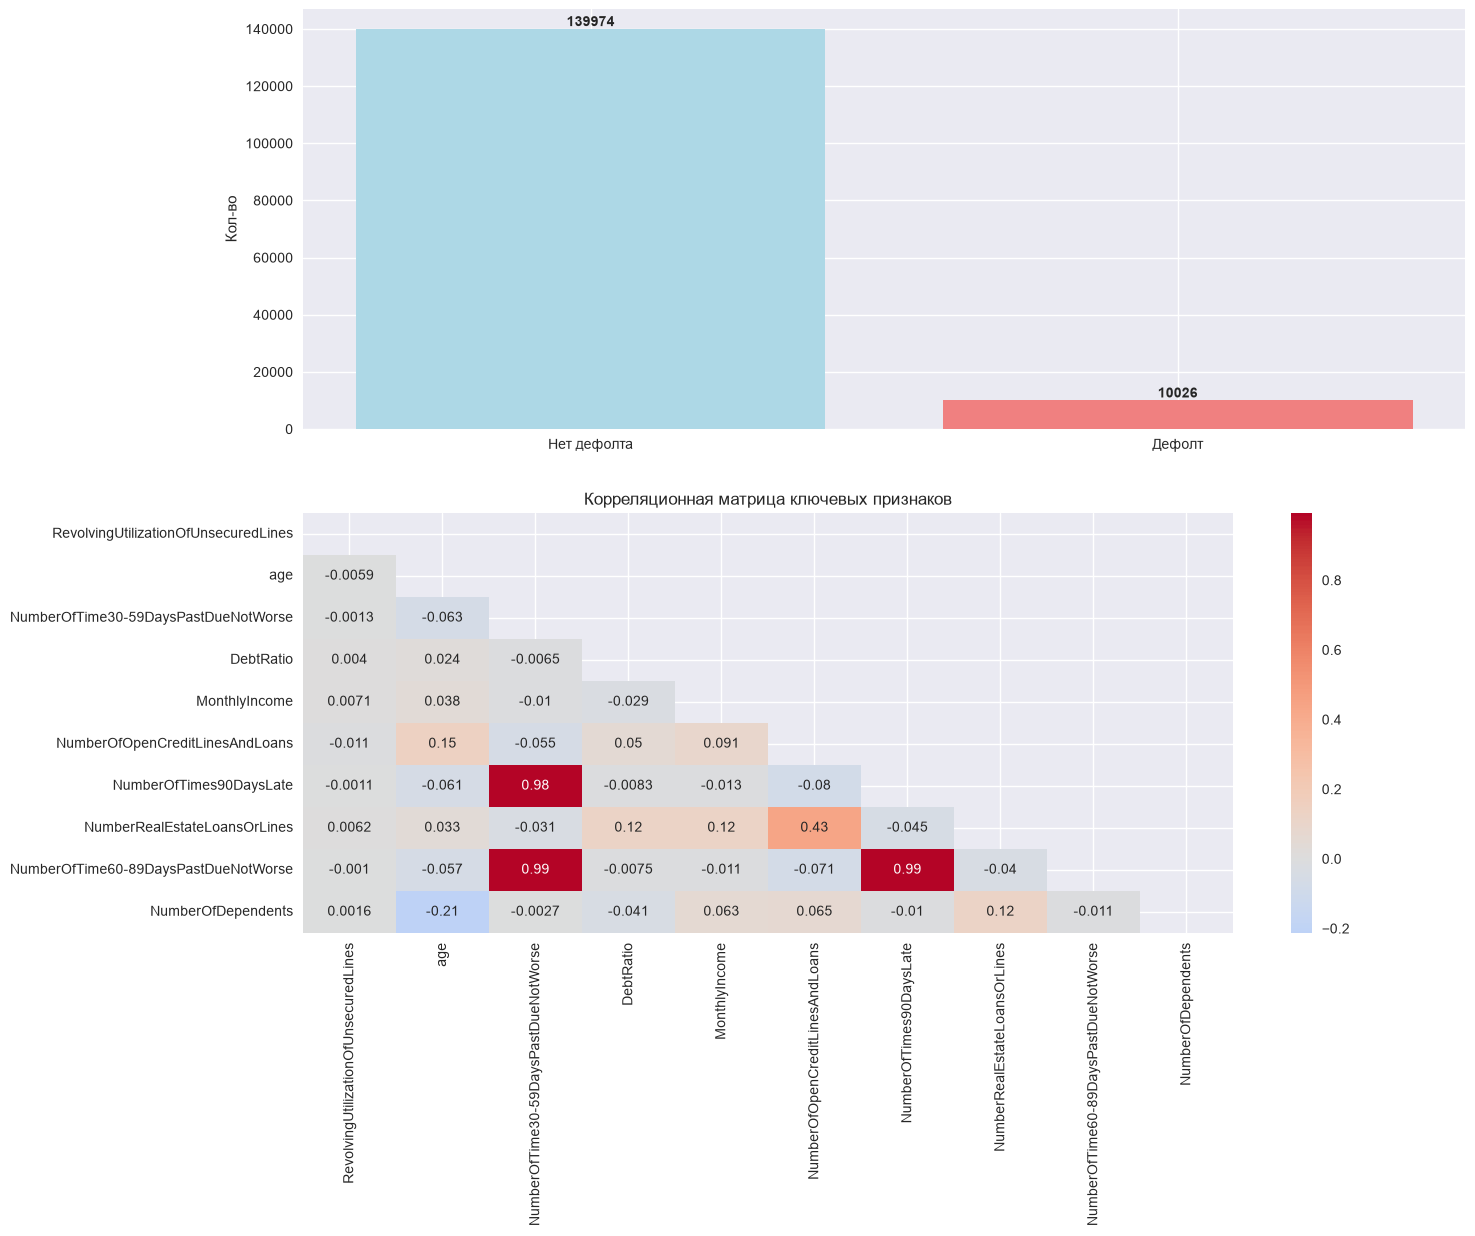

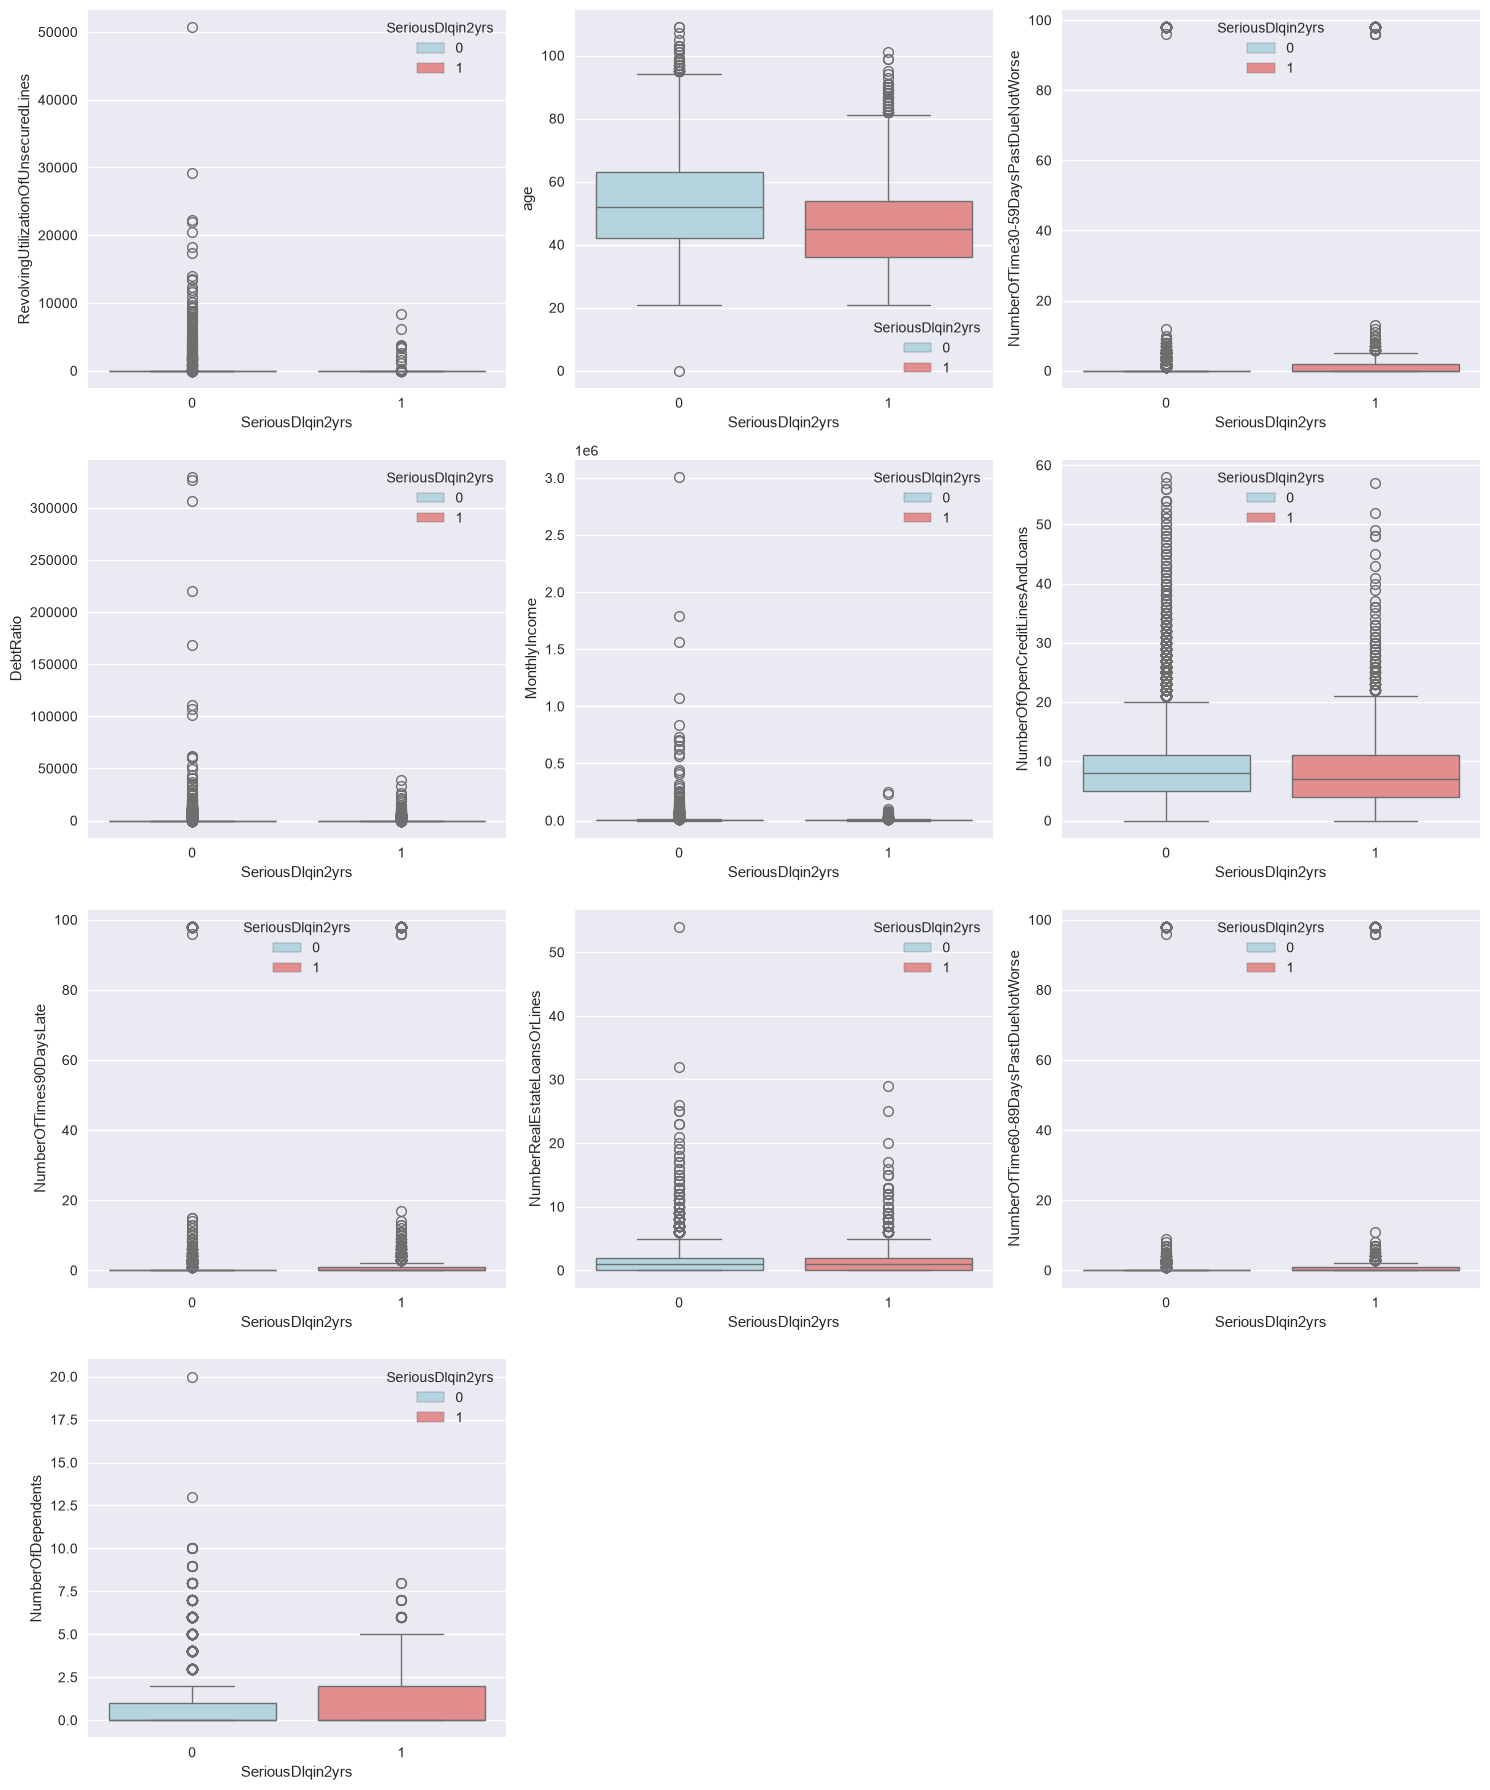

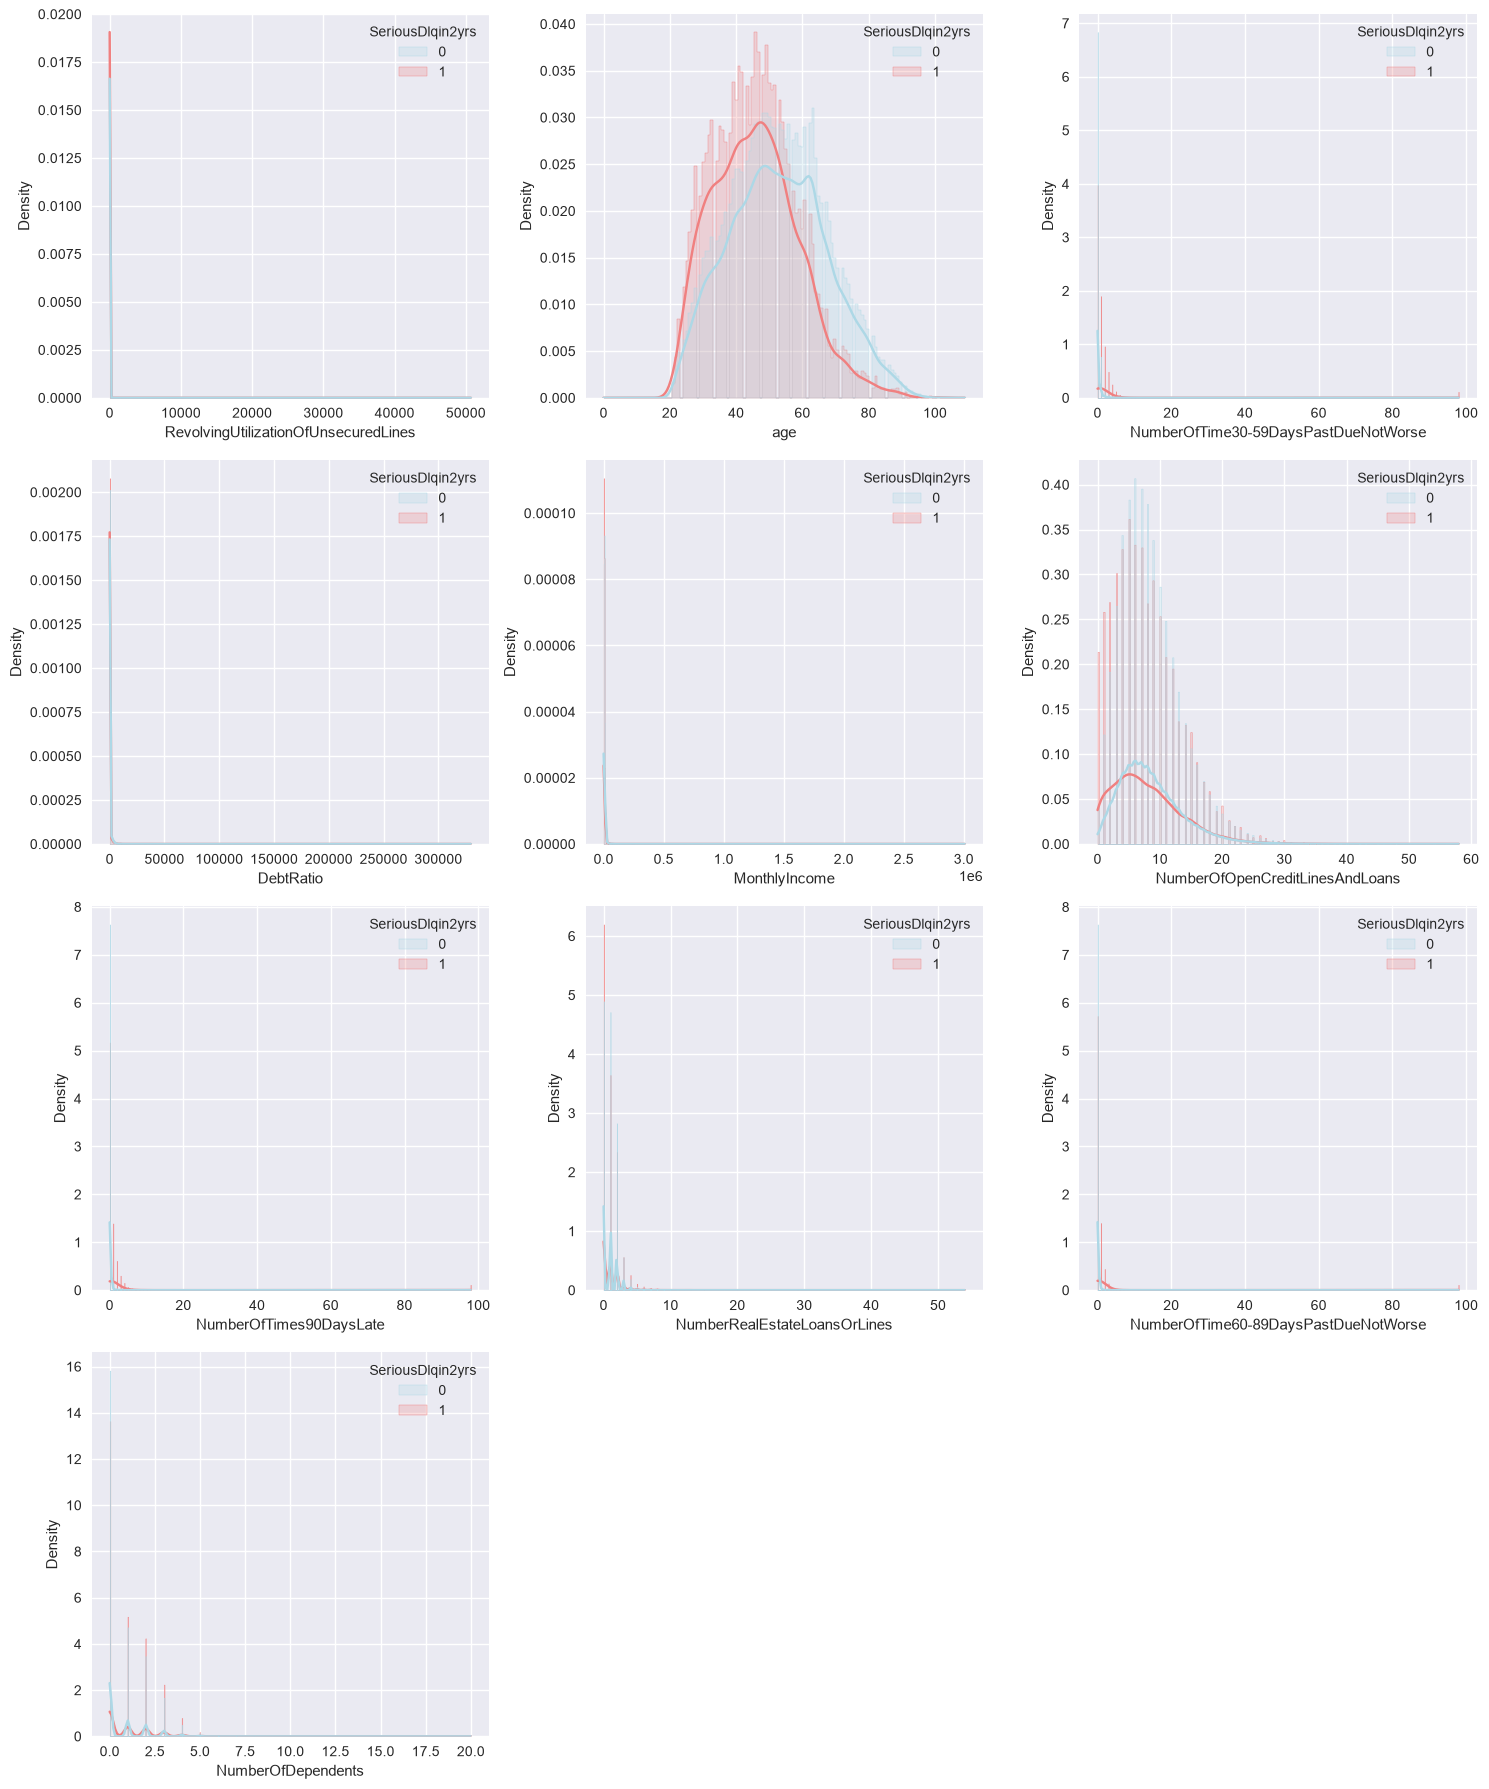

In [5]:
numeric_features = df.select_dtypes(include=['float64', 'int64']).columns.drop(['SeriousDlqin2yrs'])

fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# 1. Распределение целевой переменной
ax1 = axes[0]
target_counts = df['SeriousDlqin2yrs'].value_counts()
colors = ['lightblue', 'lightcoral']
bars = ax1.bar(['Нет дефолта', 'Дефолт'], target_counts.values, color=colors)
ax1.set_ylabel('Кол-во')
ax1.set_label('Распределение целевой переменной')
#Подписи
for bar, value in zip(bars, target_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             str(value), ha='center', va='bottom', fontweight='bold')
    
# 2. Корреляционная матрица
ax2 = axes[1]
corr_matrix = df[numeric_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0, ax=ax2)
ax2.set_title('Корреляционная матрица ключевых признаков')

EDA.plot_grid_boxplot(df, numeric_features, 'SeriousDlqin2yrs')
EDA.plot_grid_hist(df, numeric_features, 'SeriousDlqin2yrs')

In [21]:
preprocessor = UniversalPreprocessor.from_yaml("config.yaml")
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

print(f"\n🔄 Разделение данных:")
print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"Распределение классов в обучающей выборке: {y_train.value_counts().to_dict()}, т.e {y_train.value_counts()[1] / (y_train.value_counts()[0] + y_train.value_counts()[1])}")
print(f"Распределение классов в тестовой выборке: {y_test.value_counts().to_dict()}, т.e {y_test.value_counts()[1] / (y_test.value_counts()[0] + y_test.value_counts()[1])}")

preprocessor.fit(X_train)
X_train_t = preprocessor.transform(X_train)
X_test_t = preprocessor.transform(X_test)


🔄 Разделение данных:
Обучающая выборка: (120000, 10)
Тестовая выборка: (30000, 10)
Распределение классов в обучающей выборке: {0: 111979, 1: 8021}, т.e 0.06684166666666666
Распределение классов в тестовой выборке: {0: 27995, 1: 2005}, т.e 0.06683333333333333


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_recall_curve
import numpy as np

# 1. Обучение
lr = LogisticRegression(random_state=42, max_iter=10000, class_weight='balanced')
lr.fit(X_train_t, y_train)

# 2. Предсказания классов и вероятностей
y_train_pred = lr.predict(X_train_t)
y_test_pred = lr.predict(X_test_t)

y_train_proba = lr.predict_proba(X_train_t)[:, 1]
y_test_proba = lr.predict_proba(X_test_t)[:, 1]

# 3. Адекватные метрики для классификации
print("Accuracy на train:", accuracy_score(y_train, y_train_pred))
print("Accuracy на test:", accuracy_score(y_test, y_test_pred))

print("ROC-AUC на train:", roc_auc_score(y_train, y_train_proba))
print("ROC-AUC на test:", roc_auc_score(y_test, y_test_proba))

# 4. Правильный вызов Precision-Recall кривой
precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba)

Accuracy на train: 0.7611083333333334
Accuracy на test: 0.7608666666666667
ROC-AUC на train: 0.8270627218194271
ROC-AUC на test: 0.8303978578290832
